# Replikasi Klasifikasi Tumor Otak pada Citra MRI

Notebook ini digunakan untuk tugas replikasi penelitian AI. Model yang dipakai:

1. ResNet50 sebagai model utama/replikasi paper acuan.
2. EfficientNetB0 sebagai model pembanding.
3. MobileNetV2 sebagai model ringan pembanding.

> Catatan: eksperimen ini untuk tujuan akademik, bukan alat diagnosis medis.

## 1. Import Library

In [9]:

import os, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# Biar hasil lebih stabil
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('PyTorch:', torch.__version__)
print('CUDA Available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')


PyTorch: 2.5.1+cu121
CUDA Available: True
Device: NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Konfigurasi Path dan Hyperparameter

Pastikan dataset sudah diextract ke folder `Dataset/` sehingga ada folder `Training/` dan `Testing/`.

In [10]:

DATA_DIR = Path('../Dataset') if Path('../Dataset').exists() else Path('Dataset')
TRAIN_DIR = DATA_DIR / 'Training'
TEST_DIR = DATA_DIR / 'Testing'

OUT_DIR = Path('../Hasil_Eksperimen') if Path('../Hasil_Eksperimen').exists() else Path('Hasil_Eksperimen')
FIG_DIR = Path('../Gambar_Grafik') if Path('../Gambar_Grafik').exists() else Path('Gambar_Grafik')
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 8       # Ngebut: 8. Kalau ada waktu ubah ke 15-20.
LR = 1e-4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')d

print('DATA_DIR:', DATA_DIR.resolve())
print('TRAIN_DIR exists:', TRAIN_DIR.exists())
print('TEST_DIR exists:', TEST_DIR.exists())


DATA_DIR: C:\Users\hafiz\Downloads\BrainTumor_AI_StarterKit\BrainTumor_AI_StarterKit\Dataset
TRAIN_DIR exists: True
TEST_DIR exists: True


## 3. Load Dataset

In [11]:

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
test_ds = datasets.ImageFolder(TEST_DIR, transform=test_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_ds.classes
num_classes = len(class_names)
print('Classes:', class_names)
print('Train images:', len(train_ds))
print('Test images:', len(test_ds))


Classes: ['Glioma', 'Meningioma', 'No-tumor', 'Pituitary']
Train images: 5712
Test images: 1311


## 4. Cek Distribusi Dataset

,train,test
Glioma,1321,300
Meningioma,1339,306
No-tumor,1595,405
Pituitary,1457,300


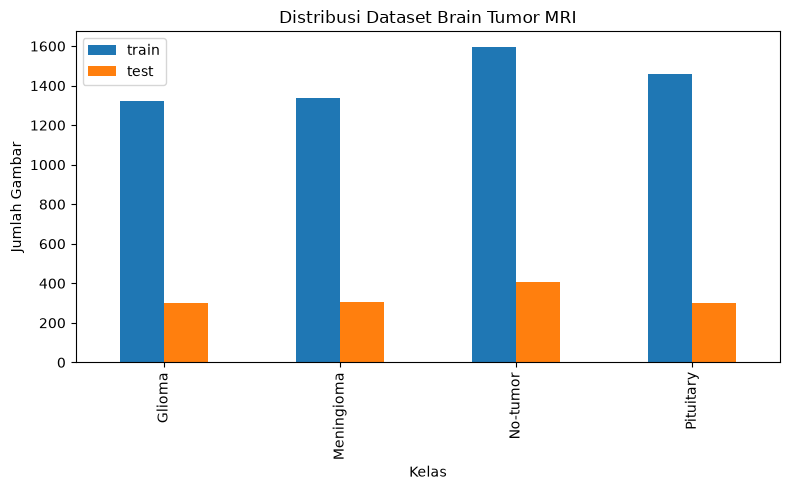

In [12]:

def count_classes(dataset):
    counts = {cls: 0 for cls in dataset.classes}
    for _, label in dataset.samples:
        counts[dataset.classes[label]] += 1
    return counts

train_counts = count_classes(train_ds)
test_counts = count_classes(test_ds)
dist_df = pd.DataFrame({'train': train_counts, 'test': test_counts})
display(dist_df)

dist_df.plot(kind='bar', figsize=(8,5))
plt.title('Distribusi Dataset Brain Tumor MRI')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.tight_layout()
plt.savefig(FIG_DIR / 'distribusi_dataset.png', dpi=300)
plt.show()


## 5. Visualisasi Contoh Gambar

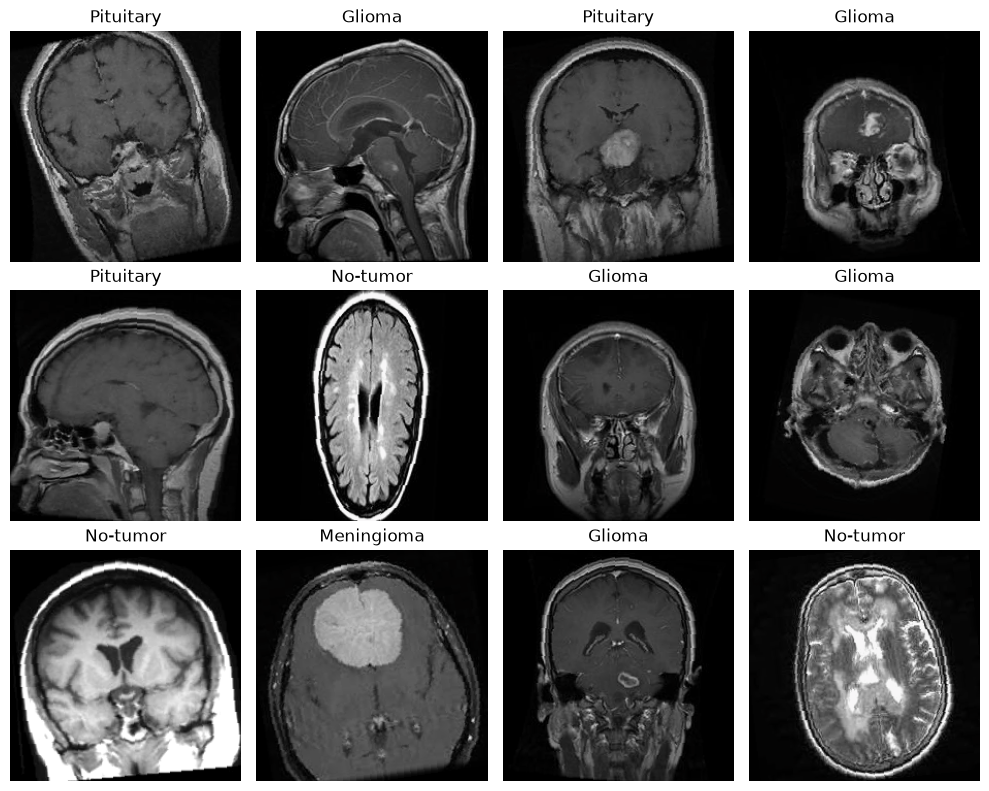

In [15]:

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(tensor.cpu() * std + mean, 0, 1)

images, labels = next(iter(train_loader))
plt.figure(figsize=(10, 8))
for i in range(min(12, len(images))):
    plt.subplot(3, 4, i+1)
    img = denormalize(images[i]).permute(1,2,0).numpy()
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'contoh_dataset.png', dpi=300)
plt.show()


## 6. Fungsi Build Model

In [16]:

def build_model(model_name, num_classes):
    model_name = model_name.lower()
    if model_name == 'resnet50':
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        for p in model.parameters():
            p.requires_grad = False
        in_features = model.fc.in_features
        model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_features, num_classes))
    elif model_name == 'efficientnet_b0':
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        for p in model.parameters():
            p.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_features, num_classes))
    elif model_name == 'mobilenet_v2':
        weights = models.MobileNet_V2_Weights.DEFAULT
        model = models.mobilenet_v2(weights=weights)
        for p in model.parameters():
            p.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_features, num_classes))
    else:
        raise ValueError('Model tidak dikenal')
    return model


## 7. Fungsi Training dan Evaluasi

In [17]:

def plot_history(history, model_name):
    epochs = history['epoch']
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['train_acc'], label='Train Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title(f'Accuracy - {model_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'grafik_accuracy_{model_name}.png', dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title(f'Loss - {model_name}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'grafik_loss_{model_name}.png', dpi=300)
    plt.show()


def evaluate_model(model, model_name, test_loader, class_names):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc=f'Evaluating {model_name}'):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report_dict).transpose()
    report_df.to_csv(OUT_DIR / f'classification_report_{model_name}.csv')

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'confusion_matrix_{model_name}.png', dpi=300)
    plt.show()

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

    with open(OUT_DIR / f'hasil_{model_name}.txt', 'w', encoding='utf-8') as f:
        f.write(f'Model: {model_name}\n')
        f.write(f'Accuracy: {acc:.4f}\n')
        f.write(f'Precision weighted: {precision:.4f}\n')
        f.write(f'Recall weighted: {recall:.4f}\n')
        f.write(f'F1 weighted: {f1:.4f}\n\n')
        f.write(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    metrics = {
        'model': model_name,
        'accuracy': acc,
        'precision_weighted': precision,
        'recall_weighted': recall,
        'f1_weighted': f1
    }
    print(metrics)
    display(report_df)
    return metrics


def train_one_model(model_name):
    model = build_model(model_name, num_classes).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
    history = {'epoch': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0
    best_path = OUT_DIR / f'best_{model_name}.pth'

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for inputs, labels in tqdm(train_loader, desc=f'{model_name} Epoch {epoch}/{EPOCHS} Train'):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in tqdm(test_loader, desc=f'{model_name} Epoch {epoch}/{EPOCHS} Valid'):
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        train_loss /= train_total
        train_acc = train_correct / train_total
        val_loss /= val_total
        val_acc = val_correct / val_total

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), best_path)

        print(f'Epoch {epoch}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}, train_loss={train_loss:.4f}, val_loss={val_loss:.4f}')

    pd.DataFrame(history).to_csv(OUT_DIR / f'history_{model_name}.csv', index=False)
    plot_history(history, model_name)
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    metrics = evaluate_model(model, model_name, test_loader, class_names)
    return model, metrics


## 8. Training Model

Kalau mau cepat, jalankan 3 model ini. Kalau waktu mepet banget, jalankan `resnet50` dan `efficientnet_b0` dulu.

resnet50 Epoch 1/8 Valid: 100%|██████████| 41/41 [00:06<00:00,  6.00it/s]


Epoch 1: train_acc=0.5641, val_acc=0.7033, train_loss=1.2349, val_loss=1.1202


resnet50 Epoch 2/8 Valid: 100%|██████████| 41/41 [00:06<00:00,  6.08it/s]


Epoch 2: train_acc=0.7458, val_acc=0.7513, train_loss=0.9997, val_loss=0.9546


resnet50 Epoch 3/8 Valid: 100%|██████████| 41/41 [00:06<00:00,  6.07it/s]


...

Epoch 6: train_acc=0.8139, val_acc=0.7933, train_loss=0.6607, val_loss=0.7017


resnet50 Epoch 7/8 Valid: 100%|██████████| 41/41 [00:06<00:00,  6.00it/s]


Epoch 7: train_acc=0.8218, val_acc=0.8002, train_loss=0.6235, val_loss=0.6463


resnet50 Epoch 8/8 Valid: 100%|██████████| 41/41 [00:06<00:00,  6.14it/s]


Epoch 8: train_acc=0.8276, val_acc=0.8055, train_loss=0.5929, val_loss=0.6320


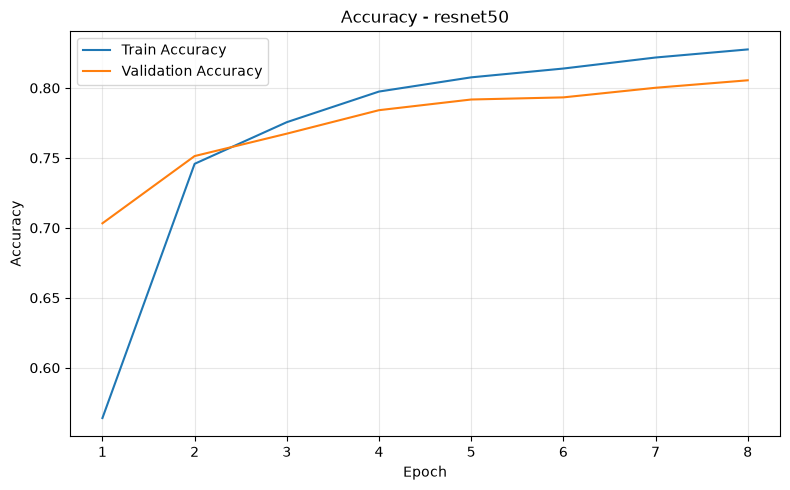

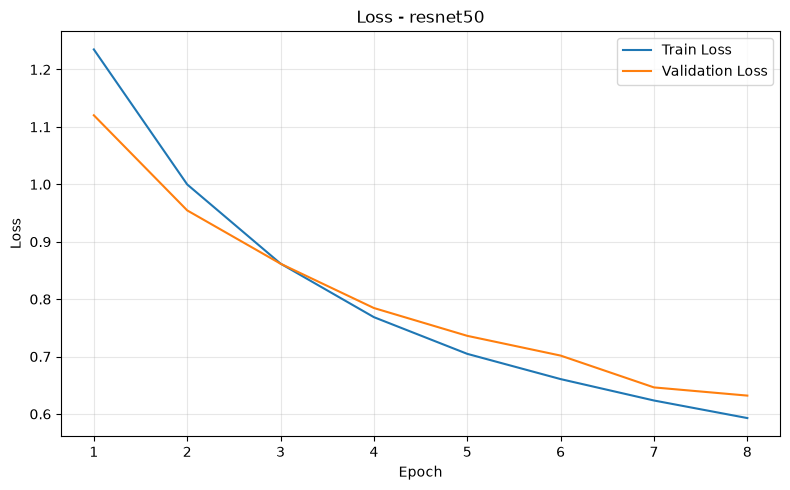

C:\Users\hafiz\AppData\Local\Temp\ipykernel_8308\1055612346.py:131: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=DE

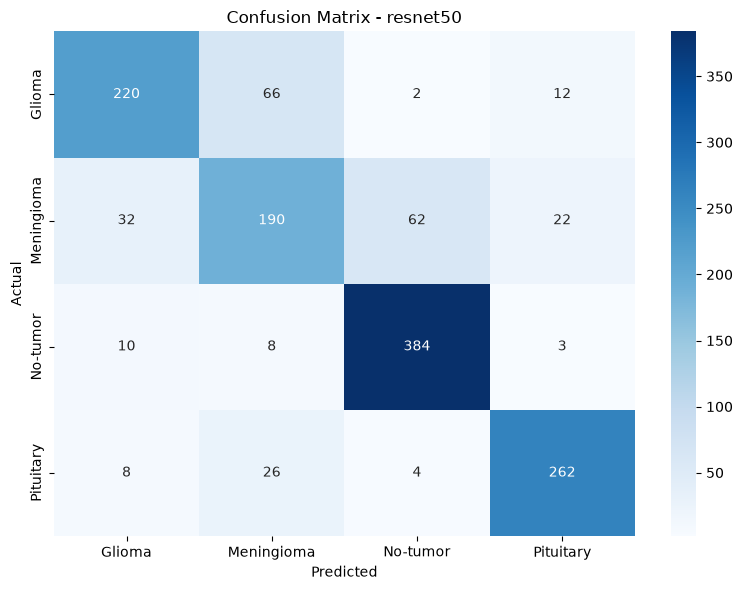

{'model': 'resnet50', 'accuracy': 0.8054919908466819, 'precision_weighted': 0.8023449685018407, 'recall_weighted': 0.8054919908466819, 'f1_weighted': 0.8024847477120316}


,precision,recall,f1-score,support
Glioma,0.814815,0.733333,0.771930,300.000000
Meningioma,0.655172,0.620915,0.637584,306.000000
No-tumor,0.849558,0.948148,0.896149,405.000000
Pituitary,0.876254,0.873333,0.874791,300.000000
accuracy,0.805492,0.805492,0.805492,0.805492
macro avg,0.798950,0.793932,0.795114,1311.000000
weighted avg,0.802345,0.805492,0.802485,1311.000000


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\hafiz/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:02<00:00, 9.49MB/s]
efficientnet_b0 Epoch 1/8 Valid: 100%|██████████| 41/41 [00:05<00:00,  7.65it/s]


Epoch 1: train_acc=0.5818, val_acc=0.7521, train_loss=1.1612, val_loss=0.9840


efficientnet_b0 Epoch 2/8 Valid: 100%|██████████| 41/41 [00:05<00:00,  7.54it/s]


...

Epoch 6: train_acc=0.8307, val_acc=0.8116, train_loss=0.5494, val_loss=0.5867


efficientnet_b0 Epoch 7/8 Valid: 100%|██████████| 41/41 [00:05<00:00,  7.13it/s]


Epoch 7: train_acc=0.8353, val_acc=0.8238, train_loss=0.5209, val_loss=0.5545


efficientnet_b0 Epoch 8/8 Valid: 100%|██████████| 41/41 [00:05<00:00,  7.13it/s]


Epoch 8: train_acc=0.8410, val_acc=0.8223, train_loss=0.5005, val_loss=0.5405


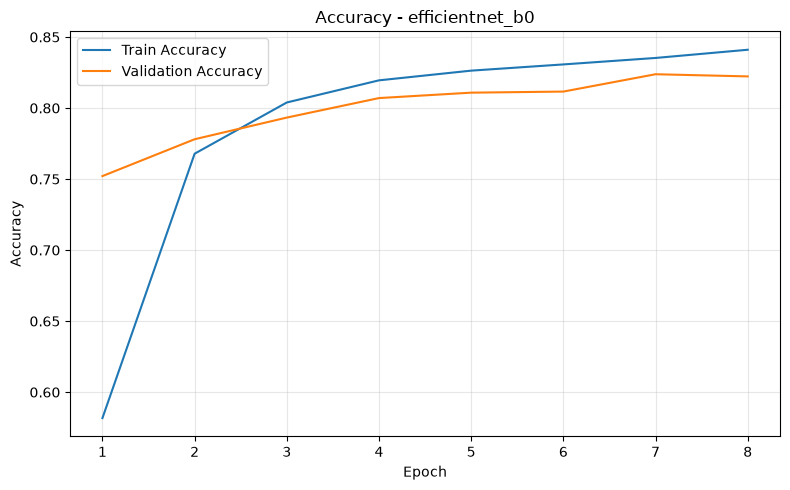

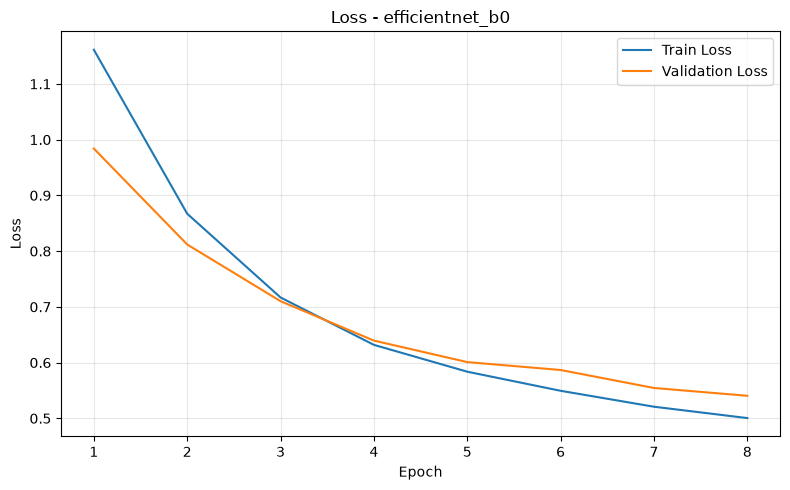

C:\Users\hafiz\AppData\Local\Temp\ipykernel_8308\1055612346.py:131: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=DE

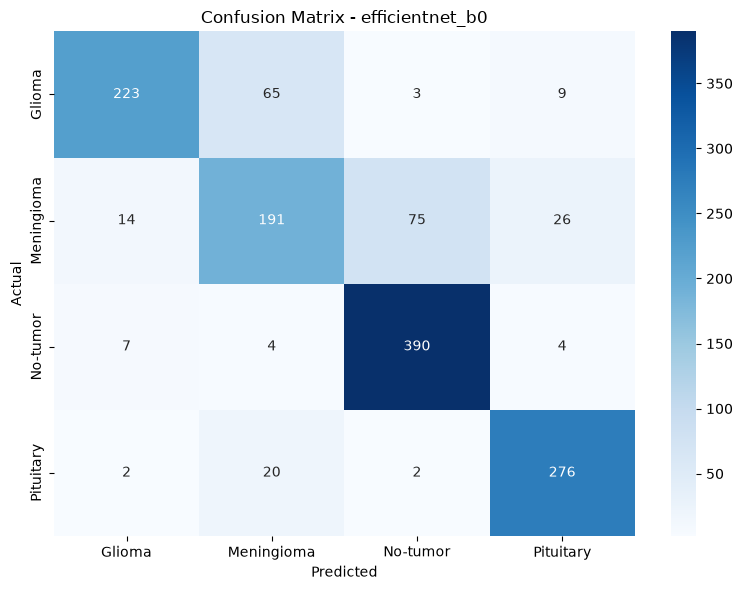

{'model': 'efficientnet_b0', 'accuracy': 0.8237986270022883, 'precision_weighted': 0.8234995472481208, 'recall_weighted': 0.8237986270022883, 'f1_weighted': 0.8198521829876573}


,precision,recall,f1-score,support
Glioma,0.906504,0.743333,0.816850,300.000000
Meningioma,0.682143,0.624183,0.651877,306.000000
No-tumor,0.829787,0.962963,0.891429,405.000000
Pituitary,0.876190,0.920000,0.897561,300.000000
accuracy,0.823799,0.823799,0.823799,0.823799
macro avg,0.823656,0.812620,0.814429,1311.000000
weighted avg,0.823500,0.823799,0.819852,1311.000000


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\hafiz/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth
100%|██████████| 13.6M/13.6M [00:01<00:00, 8.28MB/s]
mobilenet_v2 Epoch 1/8 Valid: 100%|██████████| 41/41 [00:05<00:00,  7.62it/s]


Epoch 1: train_acc=0.5263, val_acc=0.7056, train_loss=1.2381, val_loss=1.1144


mobilenet_v2 Epoch 2/8 Valid: 100%|██████████| 41/41 [00:05<00:00,  7.66it/s]


...

Epoch 6: train_acc=0.8104, val_acc=0.7841, train_loss=0.6611, val_loss=0.6985


mobilenet_v2 Epoch 7/8 Valid: 100%|██████████| 41/41 [00:05<00:00,  7.76it/s]


Epoch 7: train_acc=0.8107, val_acc=0.7956, train_loss=0.6241, val_loss=0.6632


mobilenet_v2 Epoch 8/8 Valid: 100%|██████████| 41/41 [00:05<00:00,  7.83it/s]


Epoch 8: train_acc=0.8253, val_acc=0.8055, train_loss=0.5842, val_loss=0.6421


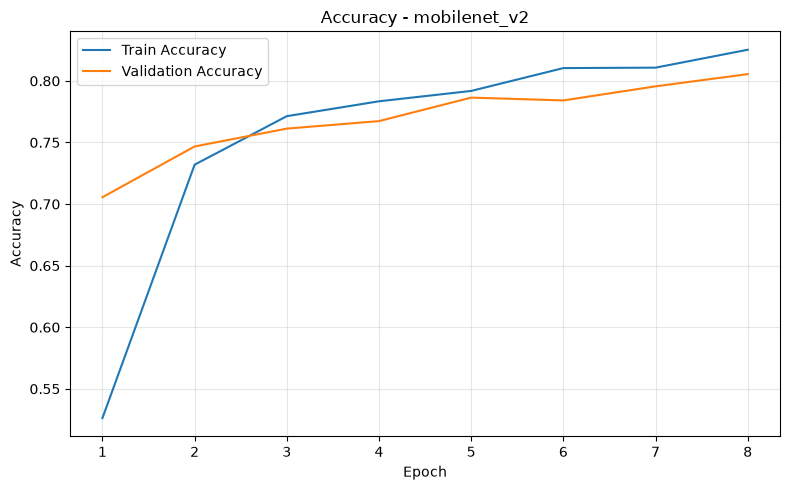

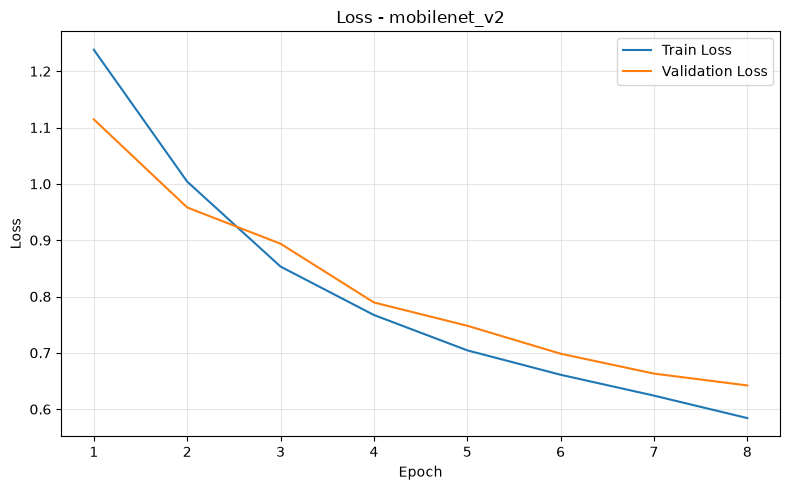

C:\Users\hafiz\AppData\Local\Temp\ipykernel_8308\1055612346.py:131: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=DE

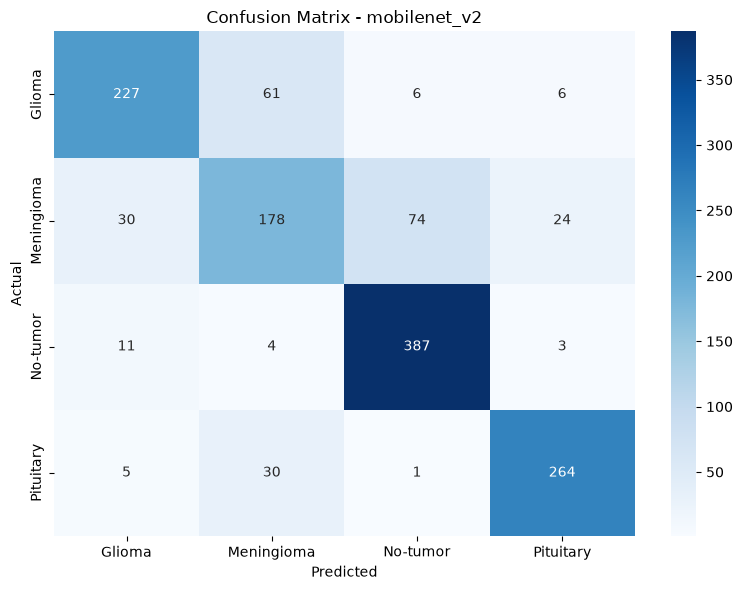

{'model': 'mobilenet_v2', 'accuracy': 0.8054919908466819, 'precision_weighted': 0.8013253591056794, 'recall_weighted': 0.8054919908466819, 'f1_weighted': 0.801098559048836}


,precision,recall,f1-score,support
Glioma,0.831502,0.756667,0.792321,300.000000
Meningioma,0.652015,0.581699,0.614853,306.000000
No-tumor,0.826923,0.955556,0.886598,405.000000
Pituitary,0.888889,0.880000,0.884422,300.000000
accuracy,0.805492,0.805492,0.805492,0.805492
macro avg,0.799832,0.793480,0.794549,1311.000000
weighted avg,0.801325,0.805492,0.801099,1311.000000


In [18]:

models_to_run = ['resnet50', 'efficientnet_b0', 'mobilenet_v2']
trained_models = {}
all_metrics = []

for model_name in models_to_run:
    model, metrics = train_one_model(model_name)
    trained_models[model_name] = model
    all_metrics.append(metrics)


## 9. Perbandingan Model

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,resnet50,0.805492,0.802345,0.805492,0.802485
1,efficientnet_b0,0.823799,0.823500,0.823799,0.819852
2,mobilenet_v2,0.805492,0.801325,0.805492,0.801099


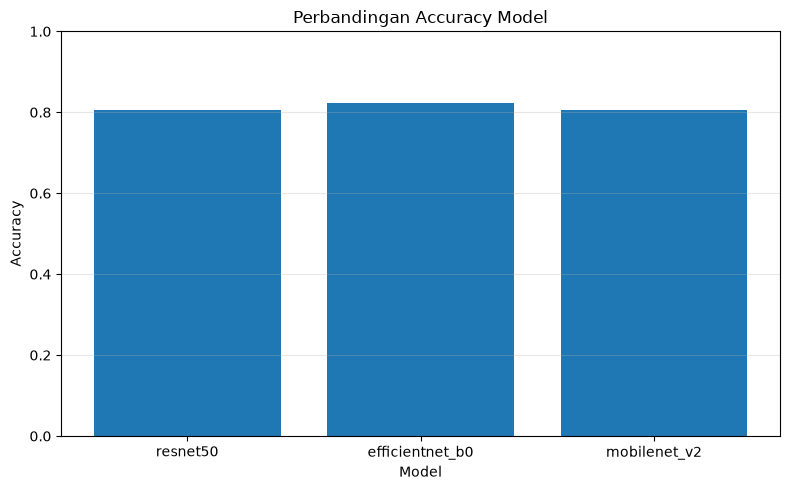

In [19]:

comparison_df = pd.DataFrame(all_metrics)
comparison_df.to_csv(OUT_DIR / 'perbandingan_model.csv', index=False)
comparison_df.to_excel(OUT_DIR / 'perbandingan_model.xlsx', index=False)
display(comparison_df)

plt.figure(figsize=(8,5))
plt.bar(comparison_df['model'], comparison_df['accuracy'])
plt.title('Perbandingan Accuracy Model')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'perbandingan_akurasi_model.png', dpi=300)
plt.show()


## 10. Grad-CAM Sederhana untuk ResNet50

Bagian ini menghasilkan visualisasi area citra MRI yang paling memengaruhi prediksi model ResNet50.

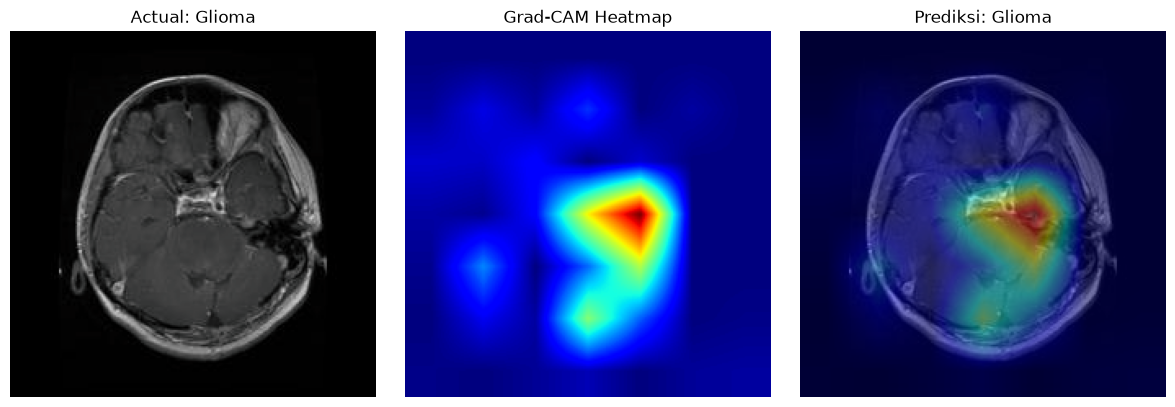

Grad-CAM berhasil dibuat.
Actual class  : Glioma
Predicted class: Glioma
File disimpan ke: ..\Gambar_Grafik\gradcam_sample_resnet50.png


In [22]:
# ============================================================
# 10. Grad-CAM Final Fix untuk ResNet50
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

# Pastikan folder gambar ada
FIG_DIR.mkdir(exist_ok=True)

# Load ulang model ResNet50 terbaik
resnet_model = build_model('resnet50', num_classes).to(DEVICE)
resnet_model.load_state_dict(
    torch.load(OUT_DIR / 'best_resnet50.pth', map_location=DEVICE, weights_only=True)
)

# Aktifkan semua gradient agar Grad-CAM bisa jalan
for param in resnet_model.parameters():
    param.requires_grad_(True)

resnet_model.eval()


class SimpleGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.hook = self.target_layer.register_forward_hook(self.forward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output
        self.activations.retain_grad()

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad(set_to_none=True)

        with torch.enable_grad():
            output = self.model(input_tensor)

            if class_idx is None:
                class_idx = output.argmax(dim=1).item()

            score = output[:, class_idx]
            score.backward()

            gradients = self.activations.grad

            if gradients is None:
                raise RuntimeError("Gradient masih kosong. Pastikan param.requires_grad sudah True.")

            # Ambil batch pertama
            gradients = gradients[0]
            activations = self.activations[0]

            # Global Average Pooling gradient
            weights = gradients.mean(dim=(1, 2), keepdim=True)

            # Weighted sum activation maps
            cam = (weights * activations).sum(dim=0)
            cam = torch.relu(cam)

            # Normalisasi 0-1
            cam = cam - cam.min()
            cam = cam / (cam.max() + 1e-8)

            return cam.detach().cpu().numpy(), class_idx

    def remove_hook(self):
        self.hook.remove()


# Ambil 1 gambar dari data testing
sample_idx = 0
img_tensor, true_label = test_ds[sample_idx]

# Tambahkan batch dimension dan aktifkan gradient input
input_tensor = img_tensor.unsqueeze(0).to(DEVICE)
input_tensor.requires_grad_(True)

# Target layer terakhir ResNet50
target_layer = resnet_model.layer4[-1]

# Jalankan Grad-CAM
gradcam = SimpleGradCAM(resnet_model, target_layer)
cam, pred_idx = gradcam.generate(input_tensor)
gradcam.remove_hook()

# Denormalisasi gambar agar tampil normal
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

img_denorm = torch.clamp(img_tensor.cpu() * std + mean, 0, 1)
img_np = img_denorm.permute(1, 2, 0).numpy()
img_uint8 = np.uint8(255 * img_np)

# Resize heatmap sesuai ukuran gambar
heatmap = cv2.resize(cam, (img_uint8.shape[1], img_uint8.shape[0]))
heatmap_uint8 = np.uint8(255 * heatmap)

# Buat heatmap warna
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# Overlay gambar asli + heatmap
overlay = np.uint8(0.6 * img_uint8 + 0.4 * heatmap_color)

# Tampilkan hasil
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_uint8)
plt.title(f"Actual: {class_names[true_label]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_uint8, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"Prediksi: {class_names[pred_idx]}")
plt.axis("off")

plt.tight_layout()

# Simpan gambar Grad-CAM
gradcam_path = FIG_DIR / "gradcam_sample_resnet50.png"
plt.savefig(gradcam_path, dpi=300, bbox_inches="tight")
plt.show()

print("Grad-CAM berhasil dibuat.")
print("Actual class  :", class_names[true_label])
print("Predicted class:", class_names[pred_idx])
print("File disimpan ke:", gradcam_path)

## 11. Ringkasan Kesimpulan Sementara

In [23]:

best_row = comparison_df.sort_values('accuracy', ascending=False).iloc[0]
print('Model terbaik:', best_row['model'])
print('Accuracy:', round(best_row['accuracy'] * 100, 2), '%')
print('Precision:', round(best_row['precision_weighted'] * 100, 2), '%')
print('Recall:', round(best_row['recall_weighted'] * 100, 2), '%')
print('F1-score:', round(best_row['f1_weighted'] * 100, 2), '%')

print('\nKalimat untuk draft jurnal:')
print(f"Berdasarkan hasil eksperimen, model {best_row['model']} memperoleh performa terbaik dengan accuracy sebesar {best_row['accuracy']*100:.2f}%, precision {best_row['precision_weighted']*100:.2f}%, recall {best_row['recall_weighted']*100:.2f}%, dan F1-score {best_row['f1_weighted']*100:.2f}%." )


Model terbaik: efficientnet_b0
Accuracy: 82.38 %
Precision: 82.35 %
Recall: 82.38 %
F1-score: 81.99 %

Kalimat untuk draft jurnal:
Berdasarkan hasil eksperimen, model efficientnet_b0 memperoleh performa terbaik dengan accuracy sebesar 82.38%, precision 82.35%, recall 82.38%, dan F1-score 81.99%.
